# Diffusion Kernel Experiment — Baseline

Systematic comparison of three affinity matrix constructions within a spectral-ALC clustering pipeline (no noise perturbation).

**Pipeline:** raw data → affinity matrix A → Laplacian L → eigendecomposition → eigenvector embedding U → ALC → cluster labels

**Affinity types compared:**
- `gaussian`  — fully connected Gaussian kernel
- `knn`       — k-nearest-neighbour Gaussian kernel
- `diffusion` — diffusion kernel (matrix exponential of k-NN affinity)

**Laplacians:** unnormalised, symmetrically normalised (SYM), random-walk normalised (RW)

**Metric:** Adjusted Rand Index (ARI) against ground-truth labels

Seeds: dataset generation = 42, ALC = 6.

---
## Section 1: Imports and Utility Functions

In [1]:
import sys
import os
import time
import warnings

# Add project root to path (this notebook lives in <root>/notebooks/)
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.linalg import eigh, eig, expm
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score
from tqdm.notebook import tqdm

from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_rings, make_two_moons

import networkx as nx


warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

print("Imports complete.")

Imports complete.


In [2]:
# ── Utility functions ─────────────────────────────────────────────────────────

def dist_mat(X):
    """Return the pairwise Euclidean distance matrix for data matrix X."""
    return cdist(X, X, "euclidean")


def check_psd(M, name="Matrix", quiet=False):
    """
    Check whether M is symmetric and positive semi-definite.

    Parameters
    ----------
    M     : ndarray, square matrix to inspect
    name  : str, label used in the printed summary
    quiet : bool, suppress printed output when True

    Returns
    -------
    dict with keys: is_symmetric, is_psd, min_eigenvalue, n_negative_eigenvalues
    """
    is_symmetric = bool(np.allclose(M, M.T))
    eigenvalues  = np.linalg.eigvalsh(M)
    is_psd       = bool(np.all(eigenvalues >= -1e-10))
    n_neg        = int(np.sum(eigenvalues < -1e-10))

    result = {
        "is_symmetric":           is_symmetric,
        "is_psd":                 is_psd,
        "min_eigenvalue":         float(eigenvalues.min()),
        "n_negative_eigenvalues": n_neg,
    }

    if not quiet:
        print(f"{name}: symmetric={is_symmetric}, PSD={is_psd}, "
              f"min_eig={eigenvalues.min():.4e}, n_neg={n_neg}")

    return result


'''def project_to_psd(A):
    """
    Project A onto the PSD cone by clipping negative eigenvalues to zero.

    Returns the nearest PSD matrix (in Frobenius norm) to A.
    """
    vals, vecs = np.linalg.eigh(A)
    vals_clipped = np.maximum(vals, 0.0)
    A_psd = vecs @ np.diag(vals_clipped) @ vecs.T
    A_psd = (A_psd + A_psd.T) / 2   # enforce numerical symmetry
    return A_psd '''


print("Utility functions defined.")

Utility functions defined.


---
## Section 2: Affinity Matrix Constructors

All three constructors accept a precomputed pairwise distance matrix and return an affinity matrix A.
The diagonal is **kept** (not zeroed) to preserve the PSD property of the Gaussian kernel.

In [3]:
# ── Affinity constructors ──────────────────────────────────────────────────────

def affinity_gaussian(dist_matrix, sigma):
    """
    Fully connected Gaussian kernel affinity matrix.

    A[i,j] = exp(-dist[i,j]^2 / (2 * sigma^2)).
    Diagonal entries are exp(0) = 1 (self-similarity kept).
    """
    return np.exp(-dist_matrix**2 / (2.0 * sigma**2))


def affinity_knn(dist_matrix, k, sigma):
    """
    k-nearest-neighbour Gaussian affinity matrix.

    Connects each point to its k nearest neighbours with a Gaussian kernel
    weight. The mask is symmetrised via the OR rule so the graph is undirected.
    The diagonal is forced True to preserve self-similarity.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    """
    n = dist_matrix.shape[0]

    # Fallback: if k >= n-1 the graph is fully connected
    if k >= n - 1:
        return affinity_gaussian(dist_matrix, sigma)

    # Step 1: k nearest neighbours for each row (skip self at sorted index 0)
    nn_idx = np.argsort(dist_matrix, axis=1)[:, 1:k + 1]   # (n, k)

    # Step 2: build directed adjacency mask
    nn_mask = np.zeros((n, n), dtype=bool)
    rows = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3: symmetrise (OR rule → undirected graph)
    sym_mask = nn_mask | nn_mask.T

    # Step 4: keep self-similarity on the diagonal
    np.fill_diagonal(sym_mask, True)

    # Step 5: full Gaussian kernel
    W = np.exp(-dist_matrix**2 / (2.0 * sigma**2))

    # Step 6: apply mask
    return W * sym_mask


def affinity_diffusion(dist_matrix, k, sigma, t):
    """
    Diffusion kernel affinity matrix.

    Builds a k-NN Gaussian affinity A, projects onto the PSD cone, then
    computes K_t = expm(-t * A_psd) via the matrix exponential.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    t           : float, diffusion time (controls smoothing)

    Returns
    -------
    K_t : ndarray (n, n), diffusion kernel (approximately PSD)

    Note: expm is scipy.linalg.expm (true matrix exponential, not elementwise).
    """
    # Step 1: base k-NN affinity
    A_knn = affinity_knn(dist_matrix, k, sigma)

    # Step 2: project onto PSD cone
    #A_psd = project_to_psd(A_knn)

    # Step 3: diffusion kernel via matrix exponential
    K_t = expm(-t * A_knn)

    # Step 4: symmetrise for numerical precision
    K_t = (K_t + K_t.T) / 2

    # Clip small negative entries (floating-point noise from expm)
    K_t = np.maximum(K_t, 0.0)

    return K_t


print("Affinity constructors defined.")

Affinity constructors defined.


---
## Section 3: Laplacian Constructor

Three Laplacian types:
- **unnorm**: L = D − A  (symmetric, PSD when A is non-negative)
- **sym**: L = I − D^{−1/2} A D^{−1/2}  (symmetric, real eigenvalues via `eigh`)
- **rw**: L = I − D^{−1} A  (asymmetric, may need real-part extraction from `eig`)

In [4]:
def build_laplacian(A, laplacian_type):
    """
    Construct a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A              : ndarray (n, n), symmetric affinity matrix
    laplacian_type : str, one of 'unnorm', 'sym', 'rw'

    Returns
    -------
    L            : ndarray (n, n)
    d            : ndarray (n,), degree vector
    is_symmetric : bool
    """
    d = A.sum(axis=1)
    n = len(d)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A
        is_symmetric = True

    elif laplacian_type == "sym":
        d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = I - D_inv_sqrt @ A @ D_inv_sqrt
        is_symmetric = True

    elif laplacian_type == "rw":
        d_inv = 1.0 / np.maximum(d, 1e-12)
        D_inv = np.diag(d_inv)
        L = I - D_inv @ A
        is_symmetric = False

    else:
        raise ValueError(
            f"Unknown laplacian_type: {laplacian_type!r}. "
            f"Choose from 'unnorm', 'sym', 'rw'."
        )

    return L, d, is_symmetric


print("Laplacian constructor defined.")

Laplacian constructor defined.


---
## Section 4: Eigensolver and Spectral Embedding

- Symmetric Laplacians (unnorm, sym): `scipy.linalg.eigh` — real, sorted ascending, orthonormal.
- Asymmetric Laplacian (rw): `scipy.linalg.eig` — strip imaginary noise, sort manually.
- SYM Laplacian: apply Ng–Jordan–Weiss row normalisation after selecting eigenvectors.

In [5]:
def spectral_embedding(L, r, is_symmetric, laplacian_type):
    """
    Compute the r-dimensional spectral embedding of Laplacian L.

    Parameters
    ----------
    L              : ndarray (n, n)
    r              : int, number of eigenvectors to retain
    is_symmetric   : bool, True → eigh; False → eig with real-part extraction
    laplacian_type : str, 'sym' triggers NJW row normalisation

    Returns
    -------
    U           : ndarray (n, r), spectral embedding
    eigenvalues : ndarray (r,), ascending eigenvalues
    """
    if is_symmetric:
        # eigh: guaranteed real, sorted ascending, orthonormal eigenvectors
        eigenvalues, eigenvectors = eigh(L)
    else:
        # eig: may return complex — strip imaginary noise then sort
        eigenvalues_c, eigenvectors_c = eig(L)
        eigenvalues  = eigenvalues_c.real
        eigenvectors = eigenvectors_c.real
        sort_idx     = np.argsort(eigenvalues)
        eigenvalues  = eigenvalues[sort_idx]
        eigenvectors = eigenvectors[:, sort_idx]

    # Select first r eigenvectors and eigenvalues (smallest eigenvalues)
    U = eigenvectors[:, :r]
    lambdas = eigenvalues[:r]

    # Ng-Jordan-Weiss row normalisation for the SYM Laplacian
    if laplacian_type == "sym":
        row_norms = np.sqrt(np.sum(U**2, axis=1, keepdims=True)) # check this 
        U = U / np.maximum(row_norms, 1e-12)

    return U, lambdas


print("spectral_embedding defined.")

spectral_embedding defined.


---
## Section 5: Single Experiment Runner

`run_single` chains all steps for one configuration: Laplacian → embedding → ALC → ARI.

**ALC note:** `ALCAdapter.fit_predict` expects an (n × n) correlation matrix directly —
it does **not** compute `corrcoef` internally. We call `np.corrcoef(U)` here before passing
to ALC. Near-constant eigenvectors (eigenvalue ≈ 0, zero variance → NaN in corrcoef) are
filtered out before that step.

In [6]:
def run_single(A, laplacian_type, r, y_true, seed=6):
    """
    Run one full spectral-ALC experiment for a given affinity matrix.

    Parameters
    ----------
    A              : ndarray (n, n), affinity matrix
    laplacian_type : str, 'unnorm' | 'sym' | 'rw'
    r              : int, embedding dimension
    y_true         : ndarray (n,), ground-truth cluster labels
    seed           : int, random seed for ALC

    Returns
    -------
    dict: ari, n_clusters_found, delta_k, spectral_gap,
          laplacian_is_psd, laplacian_min_eigenvalue, labels
    """
    q = len(np.unique(y_true))   # ground-truth number of clusters

    # Step 1: build Laplacian
    L, d, is_sym = build_laplacian(A, laplacian_type)

    # Step 2: PSD check on Laplacian (symmetric Laplacians only)
    if is_sym:
        lap_psd_info = check_psd(L, name=f"L_{laplacian_type}", quiet=True)
        lap_is_psd   = lap_psd_info["is_psd"]
        lap_min_eig  = lap_psd_info["min_eigenvalue"]
    else:
        lap_is_psd  = "N/A"
        lap_min_eig = np.nan

    # Step 3: spectral embedding
    # Fetch r+1 eigenvectors so that after filtering the constant eigenvector
    # (eigenvalue ≈ 0, near-zero variance → NaN in corrcoef) we still have r valid columns.
    U, eigenvalues = spectral_embedding(L, r, is_sym, laplacian_type)

    # Step 4: cluster with ALC
    # ALCAdapter.fit_predict takes an (n, n) correlation matrix — not the raw embedding.
    np.random.seed(seed)
    alc    = ALCAdapter()
    # Reconstruct: Phi_q @ Lambda_q @ Phi_q^T
    R_hat = U @ np.diag(1 - eigenvalues) @ U.T

    # Rescale to unit diagonal — restore valid correlation matrix
    diag = np.sqrt(np.diag(R_hat))
    diag = np.where(diag == 0, 1, diag)  # guard against zero diagonal
    R_hat = R_hat / np.outer(diag, diag)

    # Clip to [-1, 1] to correct floating point violations
    R_hat = np.clip(R_hat, -1, 1)     
    
    labels = alc.fit_predict(R_hat, cn=None) # cn=None → ALC infers cluster count

    # Step 5: evaluate
    ari              = adjusted_rand_score(y_true, labels)
    n_clusters_found = int(len(np.unique(labels)))

    # Step 6: spectral gap (λ_q − λ_{q-1}, 0-indexed)
    if len(eigenvalues) > q:
        spectral_gap = float(eigenvalues[q] - eigenvalues[q - 1])
    else:
        spectral_gap = np.nan

    return {
        "ari":                      ari,
        "n_clusters_found":         n_clusters_found,
        "delta_k":                  abs(n_clusters_found - q),
        "spectral_gap":             spectral_gap,
        "laplacian_is_psd":         lap_is_psd,
        "laplacian_min_eigenvalue": lap_min_eig,
        "labels":                   labels,
        "eigenvectors":             U,
        "eigenvalues":              eigenvalues,
        "correlation_mat":          R_hat,
    }


print("run_single defined.")

run_single defined.


---
## Section 6: Dataset Generation

| Dataset | Generator           | N   | Clusters | Dimensionality |
|---------|---------------------|-----|----------|----------------|
| blobs   | `make_blobs_convex` | 1200 | 7        | 5000           |
| circles | `make_rings`        | 1200 | 3        | 2              |
| moons   | `make_two_moons`    | 1200| 2        | 2              |

Datasets generated:
       blobs: X=(1200, 5000), classes=[0 1 2 3 4 5 6], n_clusters=7
     circles: X=(1200, 2), classes=[1 2 3], n_clusters=3
       moons: X=(1200, 2), classes=[0 1], n_clusters=2


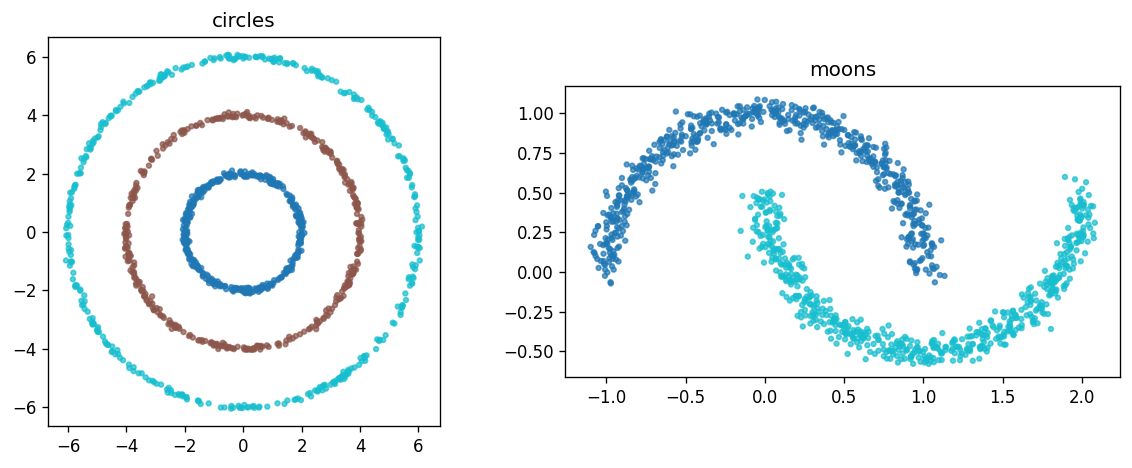

In [7]:
# ── Blobs: high-dimensional Gaussian clusters ─────────────────────────────────
X_blobs, y_blobs = make_blobs_convex(N=1200, num_clusters=7, n_features=5000, seed=42)
ds_blobs = {"name": "blobs", "X": X_blobs, "y": y_blobs, "n_clusters": 7}

# ── Circles: concentric rings ─────────────────────────────────────────────────
X_circles, y_circles = make_rings(n_points=1200, n_circles=3, noise_std=0.05, seed=42)
ds_circles = {"name": "circles", "X": X_circles, "y": y_circles, "n_clusters": 3}

# ── Moons: two interleaved half-circles ───────────────────────────────────────
X_moons, y_moons = make_two_moons(n_samples=1200, noise=0.05, seed=42)
ds_moons = {"name": "moons", "X": X_moons, "y": y_moons, "n_clusters": 2}

datasets = [ds_blobs, ds_circles, ds_moons]

print("Datasets generated:")
for ds in datasets:
    print(f"  {ds['name']:>10s}: X={ds['X'].shape}, "
          f"classes={np.unique(ds['y'])}, n_clusters={ds['n_clusters']}")

# Quick scatter for the 2-D datasets
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ds in zip(axes, [ds_circles, ds_moons]):
    ax.scatter(ds["X"][:, 0], ds["X"][:, 1],
               c=ds["y"], cmap="tab10", s=8, alpha=0.7)
    ax.set_title(ds["name"])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## Section 6b: Pipeline Sanity Check

One k-NN run per dataset at fixed, reasonable parameters to confirm the end-to-end
pipeline (affinity → Laplacian → embedding → ALC → ARI) is working before the full sweep.

In [ ]:
# ── Sanity check: one run per dataset ────────────────────────────────────────
# k-NN affinity, unnormalised Laplacian, r = true number of clusters.
# Parameters chosen from known-good region; expected ARI = 1.0 on all three.

sanity_configs = [
    {"ds": ds_blobs,   "sigma": 10,   "k": 10,  "r": 7},
    {"ds": ds_circles, "sigma": 0.2,  "k": 10, "r": 3},
    {"ds": ds_moons,   "sigma": 0.1,  "k": 10, "r": 2},
]

print(f"{'Dataset':>10s}  {'ARI':>6s}  {'k_found':>8s}  {'k_true':>7s}")
print("-" * 38)
for cfg in sanity_configs:
    ds    = cfg["ds"]
    D     = dist_mat(ds["X"])
    A     = affinity_knn(D, cfg["k"], cfg["sigma"])
    out   = run_single(A, "sym", cfg["r"], ds["y"])
    q     = ds["n_clusters"]
    print(f"{ds['name']:>10s}  {out['ari']:6.3f}  {out['n_clusters_found']:8d}  {q:7d}")


---
## Section 7: Parameter Grids

All three affinity types share the same `sigma_values` grid, allowing the bandwidth
parameter to be assessed independently of the structural parameter `k`.
- **Gaussian**: sweeps `(sigma)`.
- **k-NN**: sweeps `(sigma, k)` — the full Cartesian product.
- **Diffusion**: sweeps `(sigma, k, t)` — the full Cartesian product.

In [ ]:
param_grids = {
    "blobs": {
        "sigma_values":    [10, 25, 50, 100, 200],
        "k_values":        [5, 10, 15, 25, 50],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [7, 10, 15, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "circles": {
        "sigma_values":    [0.1, 0.25, 0.5, 1.0, 2.0],
        "k_values":        [5, 10, 15, 20, 30],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [3, 5, 10, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "moons": {
        "sigma_values":    [0.1, 0.25, 0.5, 1.0, 2.0],
        "k_values":        [5, 10, 15, 20, 30],
        "t_values":        [0.1, 0.5, 1.0, 3.0, 5.0],
        "r_values":        [2, 4, 10, 25],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
}

# Configuration count summary
# k-NN sweeps (sigma, k); diffusion sweeps (sigma, k, t).
grand_total = 0
for ds_name, g in param_grids.items():
    n_lap   = len(g["laplacian_types"])
    n_r     = len(g["r_values"])
    n_sigma = len(g["sigma_values"])
    n_gauss = n_sigma * n_lap * n_r
    n_knn   = len(g["k_values"]) * n_sigma * n_lap * n_r
    n_diff  = len(g["k_values"]) * n_sigma * len(g["t_values"]) * n_lap * n_r
    ds_total = n_gauss + n_knn + n_diff
    grand_total += ds_total
    print(f"{ds_name:>10s}: gaussian={n_gauss:4d}  knn={n_knn:5d}  "
          f"diffusion={n_diff:5d}  →  {ds_total:5d} total")

print(f"\nTotal configurations across all datasets: {grand_total}")

---
## Section 8: Main Experiment Loop

Each `run_single` call is wrapped in `try/except` — a single numerical failure will not abort
the sweep. The diffusion kernel uses `scipy.linalg.expm` (O(n³)), so timing is printed after
the first call to give a runtime estimate.

In [ ]:
# Pre-compute distance matrices (done once per dataset — reused across all affinities)
dist_matrices = {}
print("Computing distance matrices...")
for ds in datasets:
    t0 = time.time()
    dist_matrices[ds["name"]] = dist_mat(ds["X"])
    print(f"  {ds['name']:>10s}: {time.time() - t0:.2f}s")

In [ ]:
results = []

print(f"Starting sweep over {grand_total} configurations...\n")

for ds in tqdm(datasets, desc="Datasets"):
    name = ds["name"]
    y    = ds["y"]
    g    = param_grids[name]
    D    = dist_matrices[name]

    sigma_values    = g["sigma_values"]
    k_values        = g["k_values"]
    t_values        = g["t_values"]
    r_values        = g["r_values"]
    laplacian_types = g["laplacian_types"]

    # ── Affinity type 1: Gaussian ──────────────────────────────────────────────
    for sigma in tqdm(sigma_values, desc=f"{name}/gaussian", leave=False):
        A       = affinity_gaussian(D, sigma)
        aff_psd = check_psd(A, name=f"gauss σ={sigma}", quiet=True)

        for lap in laplacian_types:
            for r in r_values:
                try:
                    row = run_single(A, lap, r, y)
                    row.update({
                        "dataset":          name,
                        "affinity":         "gaussian",
                        "sigma":            sigma,
                        "k":                "N/A",
                        "t":                "N/A",
                        "rank_r":           r,
                        "laplacian":        lap,
                        "affinity_is_psd":  aff_psd["is_psd"],
                        "affinity_min_eig": aff_psd["min_eigenvalue"],
                    })
                    results.append(row)
                except Exception as e:
                    results.append({
                        "dataset": name, "affinity": "gaussian",
                        "sigma": sigma, "k": "N/A", "t": "N/A",
                        "rank_r": r, "laplacian": lap,
                        "ari": np.nan, "n_clusters_found": np.nan,
                        "delta_k": np.nan, "spectral_gap": np.nan,
                        "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                        "affinity_is_psd":  aff_psd["is_psd"],
                        "affinity_min_eig": aff_psd["min_eigenvalue"],
                        "error": str(e),
                    })

    # ── Affinity type 2: k-NN ──────────────────────────────────────────────────
    for k in tqdm(k_values, desc=f"{name}/knn", leave=False):
        for sigma in sigma_values:
            A       = affinity_knn(D, k, sigma)
            aff_psd = check_psd(A, name=f"knn k={k} σ={sigma}", quiet=True)

            for lap in laplacian_types:
                for r in r_values:
                    try:
                        row = run_single(A, lap, r, y)
                        row.update({
                            "dataset":          name,
                            "affinity":         "knn",
                            "sigma":            sigma,
                            "k":                k,
                            "t":                "N/A",
                            "rank_r":           r,
                            "laplacian":        lap,
                            "affinity_is_psd":  aff_psd["is_psd"],
                            "affinity_min_eig": aff_psd["min_eigenvalue"],
                        })
                        results.append(row)
                    except Exception as e:
                        results.append({
                            "dataset": name, "affinity": "knn",
                            "sigma": sigma, "k": k, "t": "N/A",
                            "rank_r": r, "laplacian": lap,
                            "ari": np.nan, "n_clusters_found": np.nan,
                            "delta_k": np.nan, "spectral_gap": np.nan,
                            "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                            "affinity_is_psd":  aff_psd["is_psd"],
                            "affinity_min_eig": aff_psd["min_eigenvalue"],
                            "error": str(e),
                        })

    # ── Affinity type 3: Diffusion ─────────────────────────────────────────────
    _first_diff_call = True

    for k in tqdm(k_values, desc=f"{name}/diffusion", leave=False):
        for sigma in sigma_values:
            for t in t_values:
                t_start = time.time()
                A = affinity_diffusion(D, k, sigma, t)
                diff_elapsed = time.time() - t_start

                if _first_diff_call:
                    n_expm_calls = len(k_values) * len(sigma_values) * len(t_values)
                    print(f"  [{name}] First expm call: {diff_elapsed:.2f}s  "
                          f"(est. diffusion total: "
                          f"{diff_elapsed * n_expm_calls:.0f}s for {n_expm_calls} calls)")
                    _first_diff_call = False

                aff_psd = check_psd(A, name=f"diff k={k} σ={sigma} t={t}", quiet=True)

                for lap in laplacian_types:
                    for r in r_values:
                        try:
                            row = run_single(A, lap, r, y)
                            row.update({
                                "dataset":          name,
                                "affinity":         "diffusion",
                                "sigma":            sigma,
                                "k":                k,
                                "t":                t,
                                "rank_r":           r,
                                "laplacian":        lap,
                                "affinity_is_psd":  aff_psd["is_psd"],
                                "affinity_min_eig": aff_psd["min_eigenvalue"],
                            })
                            results.append(row)
                        except Exception as e:
                            results.append({
                                "dataset": name, "affinity": "diffusion",
                                "sigma": sigma, "k": k, "t": t,
                                "rank_r": r, "laplacian": lap,
                                "ari": np.nan, "n_clusters_found": np.nan,
                                "delta_k": np.nan, "spectral_gap": np.nan,
                                "laplacian_is_psd": np.nan, "laplacian_min_eigenvalue": np.nan,
                                "affinity_is_psd":  aff_psd["is_psd"],
                                "affinity_min_eig": aff_psd["min_eigenvalue"],
                                "error": str(e),
                            })

df = pd.DataFrame(results)
print(f"\nExperiment complete. {len(df)} rows recorded.")
df.head(3)

---
## Section 9: Results Summary Tables

In [ ]:
# ── Table 1: Best ARI per (affinity, Laplacian) ───────────────────────────────
print("=" * 60)
print("TABLE 1: Best ARI per (affinity, Laplacian) combination")
print("=" * 60)

for ds_name in ["blobs", "circles", "moons"]:
    subset = df[df["dataset"] == ds_name]
    if len(subset) == 0:
        print(f"\n=== {ds_name.upper()} — no results ===")
        continue
    table = subset.groupby(["laplacian", "affinity"])["ari"].max().unstack()
    cols  = [c for c in ["gaussian", "knn", "diffusion"] if c in table.columns]
    print(f"\n=== {ds_name.upper()} — Best ARI ===")
    print(table[cols].round(3).to_string())

In [ ]:
# ── Table 2: Best parameter combinations ──────────────────────────────────────
print("=" * 60)
print("TABLE 2: Best parameter configurations per affinity type")
print("=" * 60)

for ds_name in ["blobs", "circles", "moons"]:
    print(f"\n=== {ds_name.upper()} — Best configurations ===")
    for aff in ["gaussian", "knn", "diffusion"]:
        subset = df[(df["dataset"] == ds_name) & (df["affinity"] == aff)]
        if len(subset) == 0 or subset["ari"].isna().all():
            print(f"  {aff}: no valid results")
            continue
        best = subset.loc[subset["ari"].idxmax()]
        print(f"  {aff:>10s}: ARI={best['ari']:.3f}  lap={best['laplacian']}  "
              f"sigma={best['sigma']:.4g}  k={best['k']}  t={best['t']}  "
              f"r={best['rank_r']}  clusters_found={best['n_clusters_found']}")

In [ ]:
# ── Table 3: PSD diagnostic ───────────────────────────────────────────────────
print("=" * 60)
print("TABLE 3: Fraction of configurations with PSD affinity matrix")
print("=" * 60)

for aff in ["gaussian", "knn", "diffusion"]:
    subset  = df[df["affinity"] == aff]
    n_total = len(subset)
    if n_total == 0:
        print(f"{aff:>12s}: no results")
        continue
    n_aff_psd = subset["affinity_is_psd"].eq(True).sum()
    print(f"{aff:>12s}: affinity PSD in {n_aff_psd}/{n_total} configs")

# ── Table 4: Error summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TABLE 4: Error summary")
print("=" * 60)

errors = df[df["ari"].isna()]
if len(errors) > 0:
    print(f"\n{len(errors)} configurations produced errors:")
    show_cols = [c for c in ["dataset", "affinity", "laplacian",
                              "k", "t", "rank_r", "error"]
                 if c in errors.columns]
    print(errors[show_cols].to_string())
else:
    print("\nNo errors encountered.")

---
## Section 10: Core Visualisations

Five plots examining how ARI and cluster-count accuracy vary with the key parameters.
**Plot 4** is the central plot for the paper: it shows whether the diffusion kernel
provides robustness under rank over-specification.

In [ ]:
# Shared Laplacian style map (used in Plots 1–3)
lap_styles = {
    "unnorm": dict(color="steelblue",  linestyle="-",  marker="o", label="unnorm"),
    "sym":    dict(color="crimson",    linestyle="--", marker="s", label="sym"),
    "rw":     dict(color="seagreen",   linestyle=":",  marker="^", label="rw"),
}

# ── Plot 1: ARI vs sigma — Gaussian affinity ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 1 — ARI vs σ (Gaussian affinity, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "gaussian") &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("sigma")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("sigma")
    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 2: ARI vs k — k-NN affinity ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 2 — ARI vs k (k-NN affinity, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "knn") &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("k")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("k")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 3: ARI vs t — Diffusion affinity ─────────────────────────────────────
# Fix k = 10 as a reasonable default; revisit after reviewing Plot 2.
DEFAULT_K_DIFF = 10

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle(f"Plot 3 — ARI vs t (Diffusion affinity, k={DEFAULT_K_DIFF}, r = n_clusters)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name = ds["name"]
    q       = ds["n_clusters"]
    subset  = df[(df["dataset"] == ds_name) &
                 (df["affinity"] == "diffusion") &
                 (df["k"]        == DEFAULT_K_DIFF) &
                 (df["rank_r"]   == q)]

    for lap, style in lap_styles.items():
        pts = subset[subset["laplacian"] == lap].groupby("t")["ari"].max()
        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.set_title(ds_name)
    ax.set_xlabel("t  (diffusion time)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 4: ARI vs r — all three affinities compared ─────────────────────────
# For each affinity, fix best (Laplacian + sigma/k/t) from Tables 1-2 and sweep r.
# A vertical dashed line marks the true number of clusters q.

aff_styles = {
    "gaussian":  dict(color="steelblue",  linestyle="-",  marker="o", label="Gaussian"),
    "knn":       dict(color="darkorange", linestyle="--", marker="s", label="k-NN"),
    "diffusion": dict(color="crimson",    linestyle=":",  marker="^", label="Diffusion"),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("Plot 4 — ARI vs r  (best params per affinity)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name   = ds["name"]
    q         = ds["n_clusters"]
    subset_ds = df[df["dataset"] == ds_name]

    for aff, style in aff_styles.items():
        sub = subset_ds[subset_ds["affinity"] == aff]
        if len(sub) == 0 or sub["ari"].isna().all():
            continue

        # Best Laplacian for this affinity on this dataset
        best_lap = sub.groupby("laplacian")["ari"].max().idxmax()
        sub_lap  = sub[sub["laplacian"] == best_lap]

        if aff == "gaussian":
            best_sigma = sub_lap.groupby("sigma")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["sigma"] == best_sigma]
                   .groupby("rank_r")["ari"].max())
        elif aff == "knn":
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["k"] == best_k]
                   .groupby("rank_r")["ari"].max())
        else:  # diffusion
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            best_t = (sub_lap[sub_lap["k"] == best_k]
                      .groupby("t")["ari"].max().idxmax())
            pts = (sub_lap[(sub_lap["k"] == best_k) & (sub_lap["t"] == best_t)]
                   .groupby("rank_r")["ari"].max())

        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.axvline(x=q, color="grey", linestyle="--", linewidth=1, alpha=0.7,
               label=f"r = q = {q}")
    ax.set_title(ds_name)
    ax.set_xlabel("r  (embedding dimension)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ARI")
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 5: Number of clusters found vs r ─────────────────────────────────────
# Same layout as Plot 4 but y-axis is n_clusters_found.
# A horizontal dashed line marks the ground-truth cluster count q.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Plot 5 — Clusters found vs r  (best params per affinity)",
             fontsize=12, fontweight="bold")

for ax, ds in zip(axes, datasets):
    ds_name   = ds["name"]
    q         = ds["n_clusters"]
    subset_ds = df[df["dataset"] == ds_name]

    for aff, style in aff_styles.items():
        sub = subset_ds[subset_ds["affinity"] == aff]
        if len(sub) == 0 or sub["ari"].isna().all():
            continue

        best_lap = sub.groupby("laplacian")["ari"].max().idxmax()
        sub_lap  = sub[sub["laplacian"] == best_lap]

        if aff == "gaussian":
            best_sigma = sub_lap.groupby("sigma")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["sigma"] == best_sigma]
                   .groupby("rank_r")["n_clusters_found"].mean())
        elif aff == "knn":
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            pts = (sub_lap[sub_lap["k"] == best_k]
                   .groupby("rank_r")["n_clusters_found"].mean())
        else:  # diffusion
            sub_k  = sub_lap[sub_lap["k"] != "N/A"]
            best_k = sub_k.groupby("k")["ari"].max().idxmax()
            best_t = (sub_lap[sub_lap["k"] == best_k]
                      .groupby("t")["ari"].max().idxmax())
            pts = (sub_lap[(sub_lap["k"] == best_k) & (sub_lap["t"] == best_t)]
                   .groupby("rank_r")["n_clusters_found"].mean())

        if len(pts) == 0:
            continue
        ax.plot(pts.index, pts.values, **style)

    ax.axhline(y=q, color="grey", linestyle="--", linewidth=1, alpha=0.7,
               label=f"true q = {q}")
    ax.set_title(ds_name)
    ax.set_xlabel("r  (embedding dimension)")
    ax.set_ylabel("clusters found")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 11: Affinity Graph Visualization (NetworkX)

Overlay each affinity graph on the 2D clustering solution produced by the same ALC pipeline used throughout this notebook.

- **Nodes** sit at their actual 2D coordinates, colored by ALC-assigned cluster
- **Edges** show the affinity weights; only edges above a `threshold` are drawn (keeps dense graphs readable)
- **Z-order**: edges drawn first (behind), nodes on top
- We subsample the 2D datasets to ≤ 200 points per call so NetworkX renders quickly

In [8]:
# Install NetworkX if not already present
import importlib, subprocess, sys as _sys
if importlib.util.find_spec("networkx") is None:
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "networkx", "-q"])

import networkx as nx
print(f"networkx {nx.__version__} ready.")

networkx 3.6.1 ready.


In [9]:
def plot_affinity_graph(
    coords,
    labels,
    affinity,
    threshold=0.0,
    title="",
    ax=None,
    figsize=(7, 6),
    edge_alpha=0.20,
    edge_color="#777777",
    node_size=40,
    node_alpha=0.85,
):
    """
    Overlay an affinity graph on a 2D clustering solution.

    Parameters
    ----------
    coords    : (N, 2) array — node positions (actual 2D coordinates)
    labels    : (N,) integer array — ALC cluster assignments (for node colors)
    affinity  : (N, N) affinity matrix (dense ndarray or scipy sparse)
    threshold : float — only draw edges with weight > threshold
    title     : str — plot title
    ax        : matplotlib Axes to draw into; creates a new figure when None
    figsize   : tuple — figure size when ax is None
    edge_alpha: float — edge opacity (0 invisible → 1 opaque)
    edge_color: str   — edge color
    node_size : int   — scatter marker area
    node_alpha: float — node opacity

    Returns
    -------
    fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # Handle scipy sparse input
    A = affinity.toarray() if hasattr(affinity, "toarray") else np.asarray(affinity)

    # Build NetworkX graph from upper triangle above threshold
    G = nx.Graph()
    n = len(coords)
    G.add_nodes_from(range(n))
    tri_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    rows_e, cols_e = np.where((A > threshold) & tri_mask)
    for r, c in zip(rows_e, cols_e):
        G.add_edge(int(r), int(c))

    pos = {i: (float(coords[i, 0]), float(coords[i, 1])) for i in range(n)}

    # Cluster → color mapping
    unique_labels = np.unique(labels)
    cmap          = plt.cm.tab10
    color_map     = {int(l): cmap(i / max(len(unique_labels), 1))
                     for i, l in enumerate(unique_labels)}
    node_colors   = [color_map[int(labels[i])] for i in range(n)]

    # ── Draw edges first (z-order: behind nodes) ──────────────────────────────
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha,
                           edge_color=edge_color, width=0.6)

    # ── Draw nodes on top ─────────────────────────────────────────────────────
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_size, alpha=node_alpha)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=color_map[int(l)], markersize=8,
                   label=f"Cluster {l}")
        for l in unique_labels
    ]
    ax.legend(handles=legend_handles, loc="best", fontsize=8, framealpha=0.8)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")

    return fig, ax


print("plot_affinity_graph ready.")

plot_affinity_graph ready.


### 11a — Visualization datasets

Subsample to 200 points so NetworkX renders quickly. Distance matrices are recomputed on the subsample.

In [10]:
N_VIZ = 200
rng   = np.random.default_rng(42)

idx_c         = rng.choice(len(ds_circles["y"]), size=N_VIZ, replace=False)
X_viz_c       = ds_circles["X"][idx_c]
y_viz_c       = ds_circles["y"][idx_c]
D_viz_c       = dist_mat(X_viz_c)

idx_m         = rng.choice(len(ds_moons["y"]), size=N_VIZ, replace=False)
X_viz_m       = ds_moons["X"][idx_m]
y_viz_m       = ds_moons["y"][idx_m]
D_viz_m       = dist_mat(X_viz_m)

print(f"circles subsample: {X_viz_c.shape},  moons subsample: {X_viz_m.shape}")

circles subsample: (200, 2),  moons subsample: (200, 2)


### 11b — k-NN affinity

Sparse Gaussian kernel restricted to k nearest neighbors. Edges follow the local manifold — cross-cluster edges indicate where the affinity leaks between clusters.

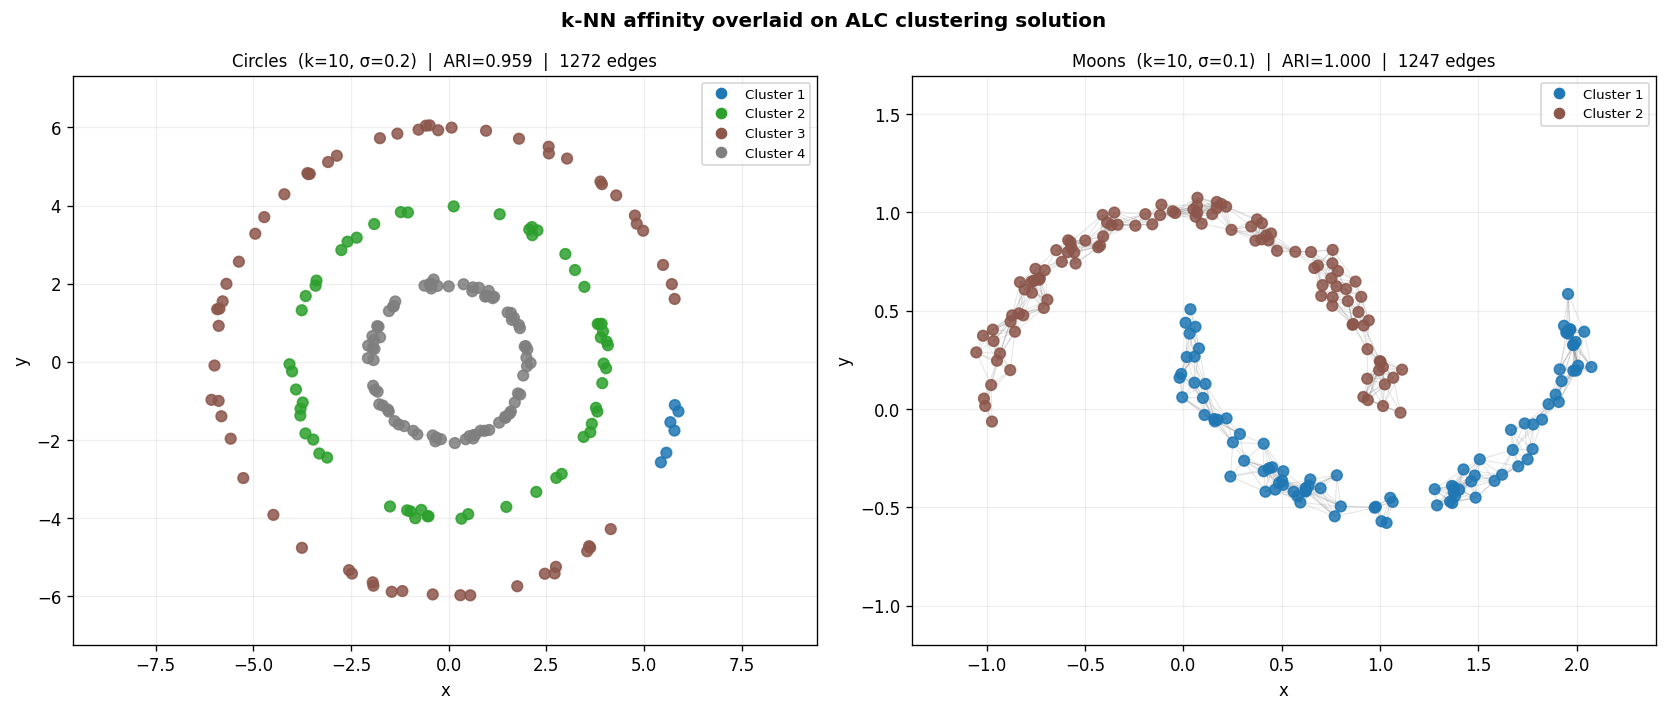

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("k-NN affinity overlaid on ALC clustering solution", fontsize=12, fontweight="bold")

for ax, (X, D, y, sigma, r, name) in zip(axes, [
    (X_viz_c, D_viz_c, y_viz_c, 0.2, 3, "Circles  (k=10, σ=0.2)"),
    (X_viz_m, D_viz_m, y_viz_m, 0.1, 2, "Moons  (k=10, σ=0.1)"),
]):
    A      = affinity_knn(D, k=10, sigma=sigma)
    result = run_single(A, "sym", r, y)
    n_edges = int((np.asarray(A) > 0).sum() // 2)

    plot_affinity_graph(
        X, result["labels"], A,
        threshold=0.1,
        title=f"{name}  |  ARI={result['ari']:.3f}  |  {n_edges} edges",
        ax=ax,
    )

plt.tight_layout()
plt.show()

### 11c — Gaussian affinity

Fully connected Gaussian kernel. Dense — use `threshold` to keep only the strongest edges visible.

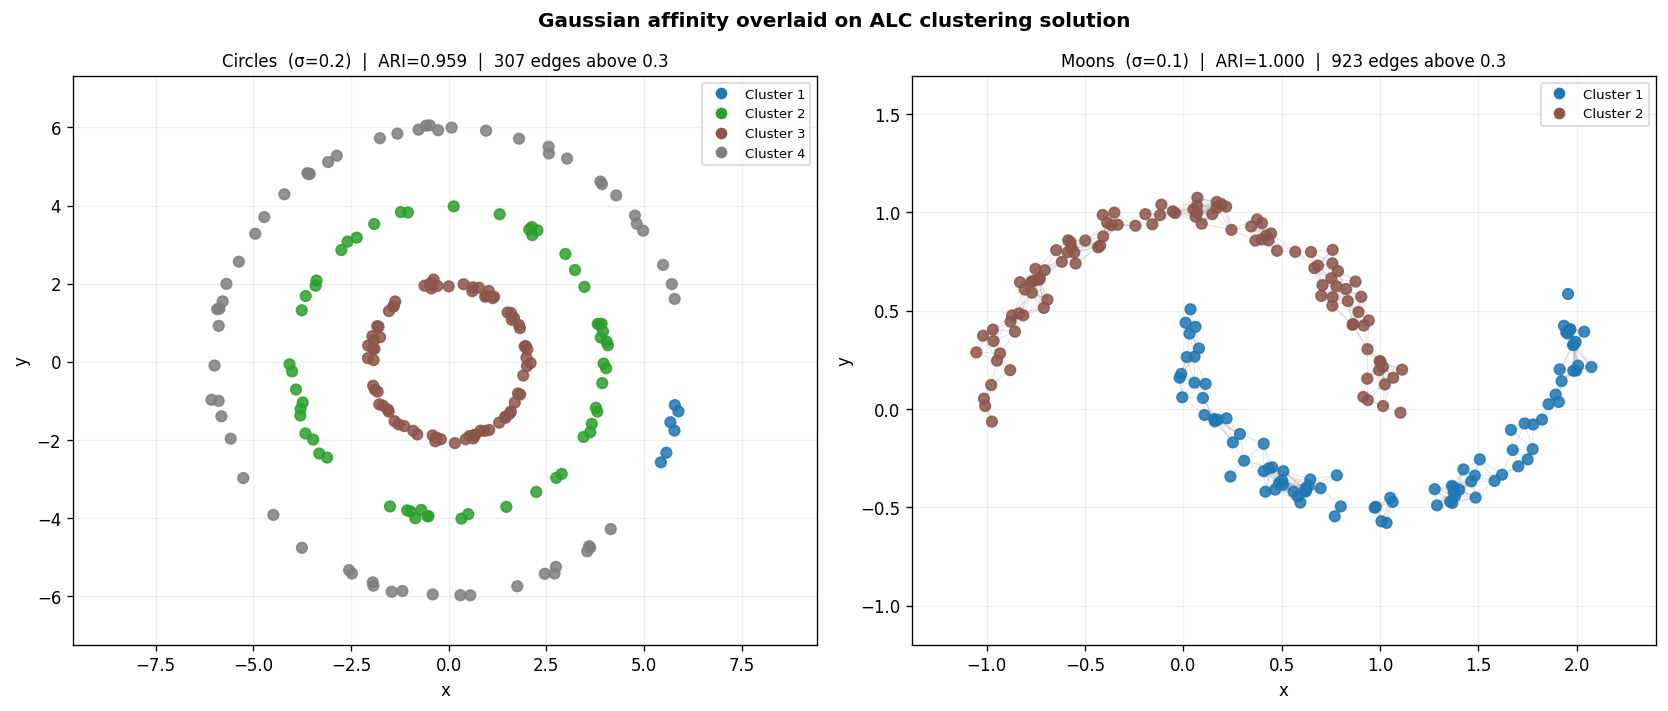

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Gaussian affinity overlaid on ALC clustering solution", fontsize=12, fontweight="bold")

GAUSS_THRESH = 0.1

for ax, (X, D, y, sigma, r, name) in zip(axes, [
    (X_viz_c, D_viz_c, y_viz_c, 0.2, 3, "Circles  (σ=0.2)"),
    (X_viz_m, D_viz_m, y_viz_m, 0.1, 2, "Moons  (σ=0.1)"),
]):
    A      = affinity_gaussian(D, sigma=sigma)
    result = run_single(A, "sym", r, y)
    n_edges = int((A > GAUSS_THRESH).sum() // 2)

    plot_affinity_graph(
        X, result["labels"], A,
        threshold=GAUSS_THRESH,
        title=f"{name}  |  ARI={result['ari']:.3f}  |  {n_edges} edges above {GAUSS_THRESH}",
        ax=ax,
    )

plt.tight_layout()
plt.show()

### 11d — Diffusion kernel affinity

Matrix exponential of the k-NN affinity: expm(−t · A_knn). Propagates similarity across graph hops — larger t = more smoothing.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Diffusion kernel overlaid on ALC clustering solution  (k=10, t=1.0)", fontsize=12, fontweight="bold")

DIFF_THRESH = 0.01

for ax, (X, D, y, sigma, r, name) in zip(axes, [
    (X_viz_c, D_viz_c, y_viz_c, 0.2, 3, "Circles  (σ=0.2, t=1.0)"),
    (X_viz_m, D_viz_m, y_viz_m, 0.1, 2, "Moons  (σ=0.1, t=1.0)"),
]):
    A      = affinity_diffusion(D, k=10, sigma=sigma, t=1.0)
    result = run_single(A, "sym", r, y)
    n_edges = int((A > DIFF_THRESH).sum() // 2)

    plot_affinity_graph(
        X, result["labels"], A,
        threshold=DIFF_THRESH,
        title=f"{name}  |  ARI={result['ari']:.3f}  |  {n_edges} edges above {DIFF_THRESH}",
        ax=ax,
    )

plt.tight_layout()
plt.show()

### 11e — σ parameter sweep (k-NN, Concentric Circles)

Four values of σ side-by-side. Both the affinity graph structure AND the ALC clustering solution update with each σ.

In [ ]:
sigma_sweep = [0.05, 0.2, 0.5, 1.5]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("k-NN affinity (k=10) on Circles — effect of σ", fontsize=12, fontweight="bold")

for ax, sigma in zip(axes, sigma_sweep):
    A      = affinity_knn(D_viz_c, k=10, sigma=sigma)
    result = run_single(A, "sym", r=3, y_true=y_viz_c)

    plot_affinity_graph(
        X_viz_c, result["labels"], A,
        threshold=0.0,
        title=f"σ={sigma}  |  ARI={result['ari']:.3f}",
        ax=ax, node_size=25, edge_alpha=0.15,
    )

plt.tight_layout()
plt.show()

### 11f — Diffusion time sweep (Two Moons)

Varying t in expm(−t · A_knn). Small t ≈ k-NN graph; large t over-smooths and links the two moons.

In [ ]:
t_sweep = [0.1, 1.0, 3.0, 7.0]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Diffusion kernel (k=10, σ=0.1) on Moons — effect of t", fontsize=12, fontweight="bold")

for ax, t in zip(axes, t_sweep):
    A      = affinity_diffusion(D_viz_m, k=10, sigma=0.1, t=t)
    result = run_single(A, "sym", r=2, y_true=y_viz_m)
    n_edges = int((A > DIFF_THRESH).sum() // 2)

    plot_affinity_graph(
        X_viz_m, result["labels"], A,
        threshold=DIFF_THRESH,
        title=f"t={t}  |  ARI={result['ari']:.3f}",
        ax=ax, node_size=25, edge_alpha=0.12,
    )

plt.tight_layout()
plt.show()

### 11g — All three methods side-by-side

Same parameters on both datasets. The clustering solution (node colors) and the affinity graph (edges) change together as the affinity method changes.

In [ ]:
K, T = 10, 1.0

viz_datasets = [
    ("Circles", X_viz_c, D_viz_c, y_viz_c, 0.2, 3),
    ("Moons",   X_viz_m, D_viz_m, y_viz_m, 0.1, 2),
]
affinity_configs = [
    ("k-NN",       lambda D, s: affinity_knn(D, K, s),           0.00),
    ("Gaussian",   lambda D, s: affinity_gaussian(D, s),          0.30),
    ("Diffusion",  lambda D, s: affinity_diffusion(D, K, s, T),   0.01),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f"All affinity methods  (k={K}, t={T})  —  ALC clustering solution",
             fontsize=13, fontweight="bold")

for row, (ds_name, X, D, y, sigma, r) in enumerate(viz_datasets):
    for col, (aff_name, aff_fn, thresh) in enumerate(affinity_configs):
        ax     = axes[row, col]
        A      = aff_fn(D, sigma)
        result = run_single(A, "sym", r, y)

        plot_affinity_graph(
            X, result["labels"], A,
            threshold=thresh,
            title=f"{ds_name} — {aff_name}  |  σ={sigma}  |  ARI={result['ari']:.3f}",
            ax=ax, node_size=20, edge_alpha=0.15,
        )

plt.tight_layout()
plt.show()

---
## Section 13: Save Results

In [ ]:
output_path = "diffusion_kernel_experiment_results_v3.csv"
df.to_csv(output_path, index=False)
print(f"Results saved: {df.shape[0]} rows × {df.shape[1]} columns → {output_path}")